[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/level2.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-PACE/level2.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/level2.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-PACE/level2.ipynb


## File Structure for Level 2 and 3 products from the Ocean Color Instrument (OCI)

**NetCDF** ([Network Common Data Format][netcdf]) is a binary file format for storing multidimensional scientific data (variables). It is optimized for array-oriented data access and support a machine-independent format for representing scientific data. Files ending in `.nc` are NetCDF files.

**XArray** is a [package][xarray] that supports the use of multi-dimensional arrays in Python. It is widely used to handle Earth observation data, which often involves multiple dimensions — for instance, longitude, latitude, time, and channels/bands.

>📘 Learning Objectives
>
> 1. Understand the differences between NetCDF file structure in Level 2 verus Level 3
> 2. How to find groups in a NetCDF file
> 3. How to use `xarray` to open OCI data
> 4. How to add indices and coordinates with `xarray`

## Import libraries

In [1]:
import cartopy.crs as ccrs
import earthaccess
import h5netcdf
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Login into NASA Earth Data

In [2]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

## Chesapeake Bay

We will be looking at data over Chesapeake Bay.

![](bbox_chesapeake.png)

## Load Level 2 data

Level 2 data is swath data and is not a regular grid. As the satelitte follows an orbit around the earth, it collects data. The data are saved in files of roughly ~5-minute chunks of the path. 

* Rows (`number_of_lines`) represent the along-track direction — each line is a step forward along the satellite's orbit.

* Columns (`pixels_per_line`) represent the cross-track direction — multiple observations made side-by-side during a single line scan.

We can use `earthaccess` to find the files that overlap with our Chesepeake Bay bounding box. We will also look for files that have low cloud cover.

In [3]:
tspan = ("2024-04-01", "2024-04-23")
bbox = (-76.75, 36.97, -75.74, 39.01)
clouds = (0, 30)

results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
len(results)

1

In [4]:
# Load the results and create a fileset
fileset = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

## Level 2 NetCDF files are grouped

The Level 2 NetCDF files are grouped. The geophysical data and navigation data (lat/lon) are in different groups in the file. Let's open the first file with `xarray`. Notice that this `xarray.Dataset` has nothing but "Attributes". We cannot use `xarray.open_dataset` to open multi-group hierarchies. Instead we use `xarray.open_datatree`.

In [6]:
xr.open_dataset(fileset[0])

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20240414T183158.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data18/sdpsoper/vdc/vpu37/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -74.16712
    geospatial_lon_min:                -112.36776
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9936428666114807

In [5]:
ds = xr.open_datatree(fileset[0], decode_timedelta = False)
ds.groups

('/',
 '/sensor_band_parameters',
 '/scan_line_attributes',
 '/geophysical_data',
 '/navigation_data',
 '/processing_control',
 '/processing_control/input_parameters',
 '/processing_control/flag_percentages')

The Rrs data is in `geophysical_data`.  

The lat/lon for the swaths is in `navigation_data`. To make maps, we want to add the lat/lon as coordinates in our xarray dataset. We will also want to add on the values for the wavelengths which is in `sensor_band_parameters`. Note, we could do this with `xr.open_datatree()` but specifying the group seems clearer.

In [6]:
f = fileset[0]
rrs = xr.open_dataset(f, group="geophysical_data")
nav = xr.open_dataset(f, group="navigation_data")
wave = xr.open_dataset(f, group="sensor_band_parameters")
rrs = rrs.assign_coords(
    longitude = nav["longitude"],
    latitude = nav["latitude"],
    wavelength_3d = wave["wavelength_3d"]
)["Rrs"]
rrs

<xarray.DataArray 'Rrs' (number_of_lines: 1710, pixels_per_line: 1272,
                         wavelength_3d: 172)> Size: 1GB
[374120640 values with dtype=float32]
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
    longitude      (number_of_lines, pixels_per_line) float32 9MB ...
    latitude       (number_of_lines, pixels_per_line) float32 9MB ...
Dimensions without coordinates: number_of_lines, pixels_per_line
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

## Plot the swath

This is pretty wide. Our bounding box is in the bottom right corner.

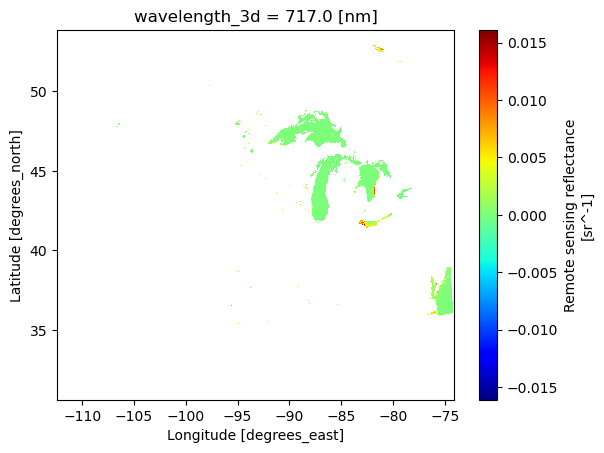

In [21]:
rrs.sel(wavelength_3d=717).plot(x="longitude", y="latitude", cmap="jet")

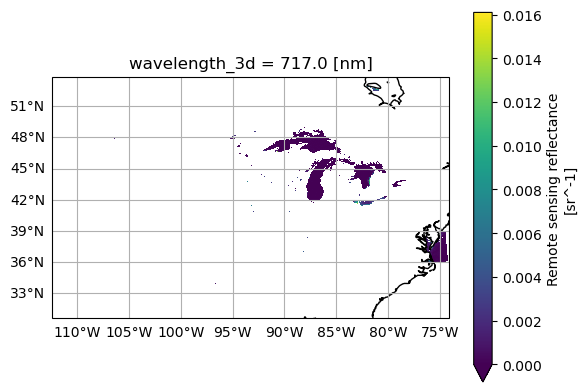

In [22]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = rrs.sel(wavelength_3d=717).plot(x="longitude", y="latitude", cmap="viridis", vmin=0, ax=ax)

Because Level 2 data is not on a grid, we cannot use `slice()` to get lat/lon subsets. Instead we need to create a mask.

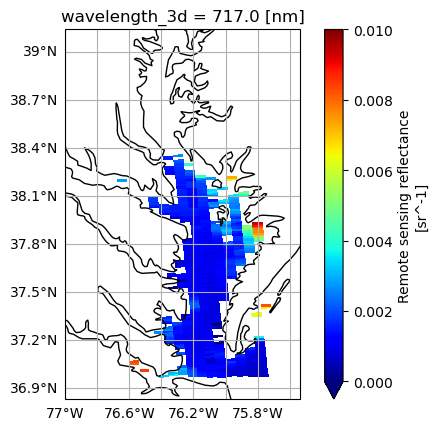

In [23]:
bbox = (-76.75, 36.97, -75.74, 39.01)
lon_min, lat_min, lon_max, lat_max = bbox

# Apply mask using where(), drop empty pixels
rrs_box = rrs.where(
    (rrs.latitude >= lat_min) & (rrs.latitude <= lat_max) &
    (rrs.longitude >= lon_min) & (rrs.longitude <= lon_max),
    drop=True
)

# Plot result
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
rrs_box.sel(wavelength_3d=717).plot(x="longitude", y="latitude", cmap="jet", vmin=0, vmax=0.01, ax=ax);

Let's plot the full "Rrs" spectrum for individual pixels. A visualization with all the pixels
wouldn't be useful, but limiting to a bounding box gives a simple way to subset pixels. Note that,
since we still don't have gridded data (i.e. our latitude and longitude coordinates are two-dimensional),
we can't `slice` on a built-in index. Without getting into anything complex, we can just box it out.

The line plotting method will only draw a line plot for 1D data, which we can get by stacking
our two spatial dimensions and choosing to show the new "pixel dimension" as different colors.

In [13]:
rrs_stack = rrs_box.stack(
    {"pixel": ["number_of_lines", "pixels_per_line"]}, create_index=False,
)
rrs_valid = rrs_stack.dropna(dim="pixel", how="all")  # drop pixels with all NaNs

In [24]:
rrs_box.sel(longitude=76.2, method="nearest")

KeyError: "no index found for coordinate 'longitude'"

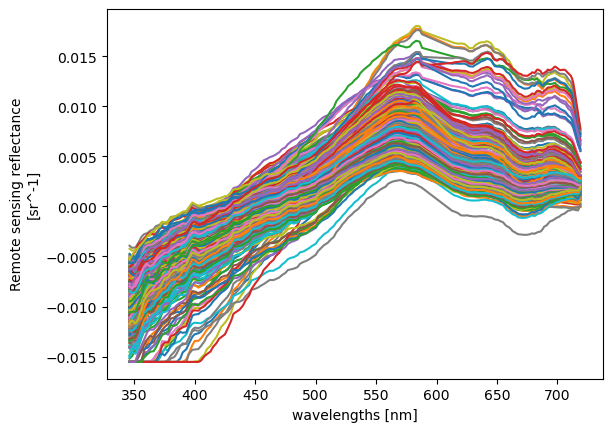

In [19]:
plot = rrs_valid.plot.line(hue="pixel", add_legend=False)

In [ ]:
r

We will go over how to plot Rrs spectra with accurate wavelength values on the x-axis in an upcoming notebook.

[Back to top](#toc)
<a name="l3"></a>
## 4. Inspecting OCI L3 File Structure


At Level-3 there are binned (B) and mapped (M) products available for OCI. The L3M remote sensing reflectance (Rrs) files contain global maps of Rrs. We'll use the same `earthaccess` method to find the data.

In [ ]:
tspan = ("2024-04-16", "2024-04-20")
bbox = (-76.75, 36.97, -75.74, 39.01)

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_RRS_NRT",
    temporal=tspan,
    bounding_box=bbox,
)

In [ ]:
paths = earthaccess.open(results)
try:
    paths[0].f.bucket
except AttributeError:
    raise "The result opened without an S3FileSystem."

OCI L3 data do not have any groups, so we can open the dataset without the `group` argument.
Let's take a look at the first file.

In [ ]:
dataset = xr.open_dataset(paths[0])
dataset

Notice that OCI L3M data has `lat` and `lon` coordinates, so it's easy to slice out a bounding box and map the "Rrs_442" variable.

In [ ]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})

rrs_442 = dataset["Rrs_442"].sel({"lat": slice(-25, -45), "lon": slice(10, 30)})
plot = rrs_442.plot(cmap="viridis", vmin=0, ax=ax)

Also becuase the L3M variables have `lat` and `lon` coordinates, it's possible to stack multiple granules along a
new dimension that corresponds to time.
Instead of `xr.open_dataset`, we use `xr.open_mfdataset` to create a single `xarray.Dataset` (the "mf" in `open_mfdataset` stands for multiple files) from an array of paths.

We also use a new search filter available in `earthaccess.search_data`: the `granule_name` argument accepts strings with the "*" wildcard. We need this to distinguish daily ("DAY") from eight-day ("8D") composites, as well as to get the 0.1 degree resolution projections.

In [ ]:
tspan = ("2024-04-12", "2024-04-24")

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL_NRT",
    temporal=tspan,
    granule_name="*.DAY.*.0p1deg.*",
)

In [ ]:
paths = earthaccess.open(results)
try:
    paths[0].f.bucket
except AttributeError:
    raise "The result opened without an S3FileSystem."

The `paths` list is sorted temporally by default, which means the shape of the `paths` array specifies the way we need to tile the files together into larger arrays. We specify `combine="nested"` to combine the files according to the shape of the array of files (or file-like objects), even though `paths` is not a "nested" list in this case. The `concat_dim="date"` argument generates a new dimension in the combined dataset, because "date" is not an existing dimension in the individual files.

In [ ]:
dataset = xr.open_mfdataset(
    paths,
    combine="nested",
    concat_dim="date",
)
dataset

A common reason to generate a single dataset from multiple, daily images is to create a composite. Compare the map from a single day ...

In [ ]:
chla = np.log10(dataset["chlor_a"])
chla.attrs.update(
    {
        "units": f'lg({dataset["chlor_a"].attrs["units"]})',
    }
)
plot = chla.sel({"date": 0}).plot(aspect=2, size=4, cmap="GnBu_r")

... to a map of average values, skipping "NaN" values that result from clouds.

In [ ]:
chla_avg = chla.mean("date")
chla_avg.attrs.update(
    {
        "long_name": chla.attrs["long_name"],
        "units": f'lg({chla.attrs["units"]})',
    }
)
plot = chla_avg.plot(aspect=2, size=4, cmap="GnBu_r")

<div class="alert alert-info" role="alert">
<p>You have completed the notebook on OCI file structure. More notebooks are comming soon!</p>
</div>